In [1]:
import os
import numpy as np

BASE_PATH = "../"


train_data = np.load(os.path.join(BASE_PATH, "tow_ids_train_dwt.npz"))

X = train_data["X"]
y = train_data["y"]

print(X.shape, y.shape)

(13165, 32, 32, 3) (13165,)


In [2]:
iid_path = os.path.join(BASE_PATH, "forFL/partition_iid")
noniid_path = os.path.join(BASE_PATH, "forFL/partition_noniid_label_skew")

os.makedirs(iid_path, exist_ok=True)
os.makedirs(noniid_path, exist_ok=True)

In [3]:
def save_client_data(base_path, client_id, X, y):
    file_path = os.path.join(base_path, f"client_{client_id}.npz")
    np.savez_compressed(file_path, X=X, y=y)

In [4]:
from sklearn.utils import shuffle

NUM_CLIENTS = 4

X_shuffled, y_shuffled = shuffle(X, y, random_state=42)

split_X = np.array_split(X_shuffled, NUM_CLIENTS)
split_y = np.array_split(y_shuffled, NUM_CLIENTS)

for i in range(NUM_CLIENTS):
    save_client_data(iid_path, i, split_X[i], split_y[i])

    unique, counts = np.unique(split_y[i], return_counts=True)
    print(f"Client {i} IID:", dict(zip(unique, counts)))

Client 0 IID: {np.int64(0): np.int64(1650), np.int64(1): np.int64(1642)}
Client 1 IID: {np.int64(0): np.int64(1666), np.int64(1): np.int64(1625)}
Client 2 IID: {np.int64(0): np.int64(1606), np.int64(1): np.int64(1685)}
Client 3 IID: {np.int64(0): np.int64(1641), np.int64(1): np.int64(1650)}


In [5]:
# Pisahkan berdasarkan label
X_0 = X[y == 0]
y_0 = y[y == 0]

X_1 = X[y == 1]
y_1 = y[y == 1]

# Shuffle biar gak bias urutan
X_0, y_0 = shuffle(X_0, y_0, random_state=42)
X_1, y_1 = shuffle(X_1, y_1, random_state=42)

In [6]:
# panjang data
n0 = len(X_0)
n1 = len(X_1)

# rasio berdasarkan pola lama
# 8000 : 500 ≈ 94% : 6%
# 8000-8500 (500) ≈ 6%
# 8500-10000 (1500) ≈ 17%
# sisanya ≈ 83% dst (relatif terhadap total)

def s(arr, start, end):
    start, end = int(start), int(end)
    if start >= len(arr):
        return arr[:1]
    return arr[start:end] if end > start else arr[start:start+1]

# ---- Client 0 (mostly class 0) ----
c0_X = np.concatenate([
    s(X_0, 0, 0.8*n0),      # besar dari class 0
    s(X_1, 0, 0.05*n1)      # kecil dari class 1
])
c0_y = np.concatenate([
    s(y_0, 0, 0.8*n0),
    s(y_1, 0, 0.05*n1)
])

# ---- Client 1 (mostly class 1) ----
c1_X = np.concatenate([
    s(X_0, 0.8*n0, 0.85*n0),
    s(X_1, 0.05*n1, 0.85*n1)
])
c1_y = np.concatenate([
    s(y_0, 0.8*n0, 0.85*n0),
    s(y_1, 0.05*n1, 0.85*n1)
])

# ---- Client 2 (balanced-ish) ----
c2_X = np.concatenate([
    s(X_0, 0.85*n0, 0.95*n0),
    s(X_1, 0.85*n1, 0.95*n1)
])
c2_y = np.concatenate([
    s(y_0, 0.85*n0, 0.95*n0),
    s(y_1, 0.85*n1, 0.95*n1)
])

# ---- Client 3 (small + skewed) ----
c3_X = np.concatenate([
    s(X_0, 0.95*n0, n0),
    s(X_1, 0.95*n1, n1)
])
c3_y = np.concatenate([
    s(y_0, 0.95*n0, n0),
    s(y_1, 0.95*n1, n1)
])

In [7]:
clients = [(c0_X, c0_y), (c1_X, c1_y), (c2_X, c2_y), (c3_X, c3_y)]

for i, (cX, cy) in enumerate(clients):
    save_client_data(noniid_path, i, cX, cy)

    unique, counts = np.unique(cy, return_counts=True)
    print(f"Client {i} Non-IID:", dict(zip(unique, counts)))

Client 0 Non-IID: {np.int64(0): np.int64(5250), np.int64(1): np.int64(330)}
Client 1 Non-IID: {np.int64(0): np.int64(328), np.int64(1): np.int64(5281)}
Client 2 Non-IID: {np.int64(0): np.int64(656), np.int64(1): np.int64(660)}
Client 3 Non-IID: {np.int64(0): np.int64(329), np.int64(1): np.int64(331)}


In [8]:
iid_path = os.path.join(BASE_PATH, "forFL/partition_iid")
noniid_path = os.path.join(BASE_PATH, "forFL/partition_noniid_label_skew")

def load_clients(path):
    clients = []
    for i in range(4):
        data = np.load(os.path.join(path, f"client_{i}.npz"))
        clients.append((data["X"], data["y"]))
    return clients

iid_clients = load_clients(iid_path)
noniid_clients = load_clients(noniid_path)

In [9]:
def get_distribution(clients):
    dist = []
    for X, y in clients:
        unique, counts = np.unique(y, return_counts=True)
        d = dict(zip(unique, counts))
        dist.append(d)
    return dist

iid_dist = get_distribution(iid_clients)
noniid_dist = get_distribution(noniid_clients)

print("IID:", iid_dist)
print("Non-IID:", noniid_dist)

IID: [{np.int64(0): np.int64(1650), np.int64(1): np.int64(1642)}, {np.int64(0): np.int64(1666), np.int64(1): np.int64(1625)}, {np.int64(0): np.int64(1606), np.int64(1): np.int64(1685)}, {np.int64(0): np.int64(1641), np.int64(1): np.int64(1650)}]
Non-IID: [{np.int64(0): np.int64(5250), np.int64(1): np.int64(330)}, {np.int64(0): np.int64(328), np.int64(1): np.int64(5281)}, {np.int64(0): np.int64(656), np.int64(1): np.int64(660)}, {np.int64(0): np.int64(329), np.int64(1): np.int64(331)}]


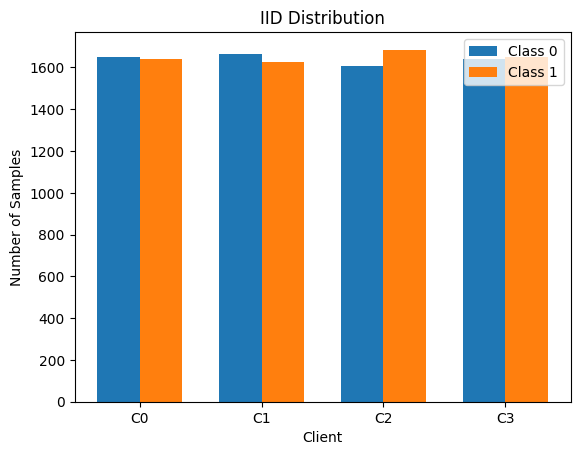

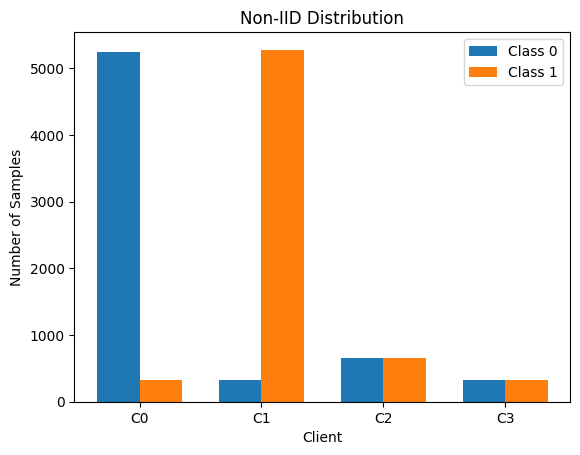

In [10]:
import matplotlib.pyplot as plt

def plot_distribution(dist, title):
    clients = range(len(dist))
    
    class_0 = [d.get(0, 0) for d in dist]
    class_1 = [d.get(1, 0) for d in dist]

    x = np.arange(len(clients))
    width = 0.35

    plt.figure()
    plt.bar(x - width/2, class_0, width, label='Class 0')
    plt.bar(x + width/2, class_1, width, label='Class 1')

    plt.xlabel("Client")
    plt.ylabel("Number of Samples")
    plt.title(title)
    plt.xticks(x, [f"C{i}" for i in clients])
    plt.legend()
    plt.show()

plot_distribution(iid_dist, "IID Distribution")
plot_distribution(noniid_dist, "Non-IID Distribution")

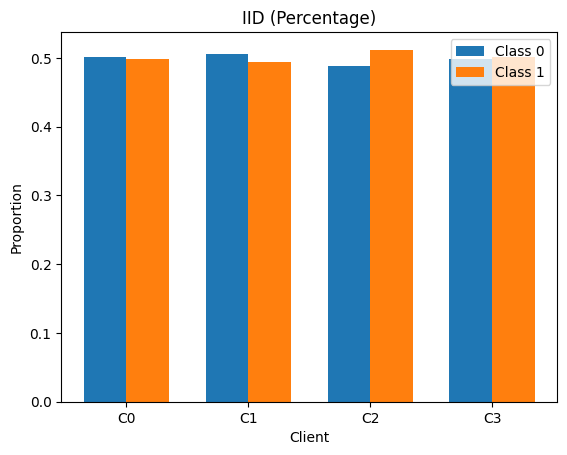

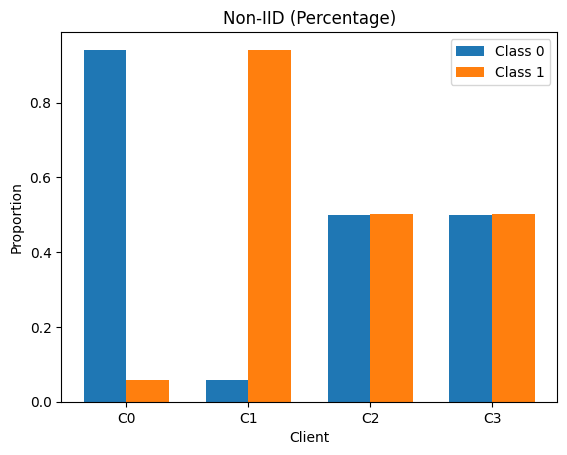

In [11]:
def plot_percentage(dist, title):
    clients = range(len(dist))
    
    class_0 = []
    class_1 = []

    for d in dist:
        total = sum(d.values())
        class_0.append(d.get(0,0)/total)
        class_1.append(d.get(1,0)/total)

    x = np.arange(len(clients))
    width = 0.35

    plt.figure()
    plt.bar(x - width/2, class_0, width, label='Class 0')
    plt.bar(x + width/2, class_1, width, label='Class 1')

    plt.xlabel("Client")
    plt.ylabel("Proportion")
    plt.title(title + " (Percentage)")
    plt.xticks(x, [f"C{i}" for i in clients])
    plt.legend()
    plt.show()

plot_percentage(iid_dist, "IID")
plot_percentage(noniid_dist, "Non-IID")